In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [3]:
DATASET_PATH = "/content/data/kaggle_3m"

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

In [5]:
IMG_SIZE = 128

images = []
masks = []

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)
    image_files = [f for f in files if f.endswith(".tif") and "_mask" not in f]

    for image_file in image_files:
        image_path = os.path.join(folder_path, image_file)
        mask_file = image_file.replace(".tif", "_mask.tif")
        mask_path = os.path.join(folder_path, mask_file)

        if not os.path.exists(mask_path):
            continue

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        image = image / 255.0
        mask = mask / 255.0

        images.append(image)
        masks.append(mask)

images = np.array(images).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
masks = np.array(masks).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: (3929, 128, 128, 1)
Masks shape: (3929, 128, 128, 1)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3143, 128, 128, 1)
X_test: (786, 128, 128, 1)
y_train: (3143, 128, 128, 1)
y_test: (786, 128, 128, 1)


In [7]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )


def iou_score(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

2 — U-Net model

In [8]:
def unet_model(input_size=(128, 128, 1)):
    inputs = layers.Input(input_size)

    c1 = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(p1)
    c2 = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(p2)
    c3 = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(c3)

    u2 = layers.UpSampling2D((2, 2))(c3)
    u2 = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(u2)
    u2 = layers.Concatenate()([u2, c2])

    c4 = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(u2)
    c4 = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(c4)

    u1 = layers.UpSampling2D((2, 2))(c4)
    u1 = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(u1)
    u1 = layers.Concatenate()([u1, c1])

    c5 = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(u1)
    c5 = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(c5)

    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid")(c5)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

3 — Compile

In [9]:
model = unet_model(input_size=(128, 128, 1))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", dice_coefficient, iou_score]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,040 │ up_sampling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_6[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     73,792 │ up_sampling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_9[0][0], 

 Total params: 2,066,497 (7.88 MB)

 Trainable params: 2,066,497 (7.88 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=16
)

Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 74s 291ms/step - accuracy: 0.9841 - dice_coefficient: 0.0613 - iou_score: 0.0320 - loss: 0.0607 - val_accuracy: 0.9897 - val_dice_coefficient: 0.1030 - val_iou_score: 0.0547 - val_loss: 0.0341
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.9886 - dice_coefficient: 0.1038 - iou_score: 0.0555 - loss: 0.0389 - val_accuracy: 0.9897 - val_dice_coefficient: 0.1598 - val_iou_score: 0.0883 - val_loss: 0.0326
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.9887 - dice_coefficient: 0.1318 - iou_score: 0.0722 - loss: 0.0371 - val_accuracy: 0.9899 - val_dice_coefficient: 0.1467 - val_iou_score: 0.0812 - val_loss: 0.0323
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 27s 153ms/step - accuracy: 0.9891 - dice_coefficient: 0.1632 - iou_score: 0.0910 - loss: 0.0350 - val_accuracy: 0.9904 - val_dice_coefficient: 0.2109 - val_iou_score: 0.1209 - val_loss: 0.0307
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0

In [11]:
results = model.evaluate(X_test, y_test)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Dice Coefficient:", results[2])
print("IoU Score:", results[3])

25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 356ms/step - accuracy: 0.9953 - dice_coefficient: 0.7033 - iou_score: 0.5459 - loss: 0.0106
Test Loss: 0.010642670094966888
Test Accuracy: 0.9953250885009766
Dice Coefficient: 0.7032991647720337
IoU Score: 0.5458550453186035


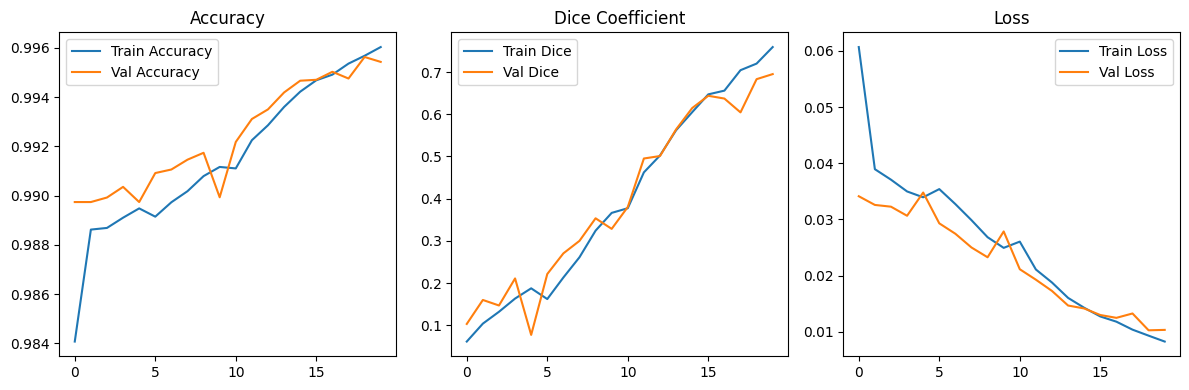

In [12]:
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 3, 2)
plt.plot(history.history["dice_coefficient"], label="Train Dice")
plt.plot(history.history["val_dice_coefficient"], label="Val Dice")
plt.legend()
plt.title("Dice Coefficient")

plt.subplot(1, 3, 3)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.tight_layout()
plt.savefig("results/training_metrics.png", dpi=300)
plt.show()

In [13]:
predictions = model.predict(X_test[:5])
predictions = (predictions > 0.5).astype("uint8")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [14]:
def overlay_mask(image, mask, alpha=0.4):

    image = (image * 255).astype("uint8")

    overlay = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    overlay[mask > 0] = [255, 0, 0]

    blended = cv2.addWeighted(
        cv2.cvtColor(image, cv2.COLOR_GRAY2BGR),
        1 - alpha,
        overlay,
        alpha,
        0
    )

    return blended

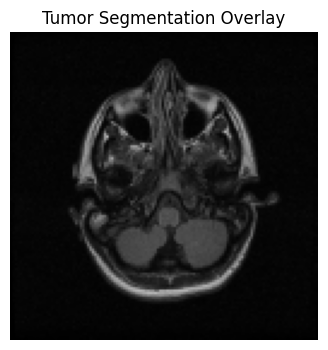

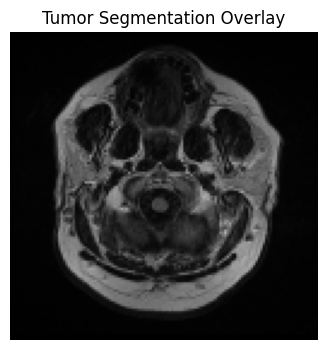

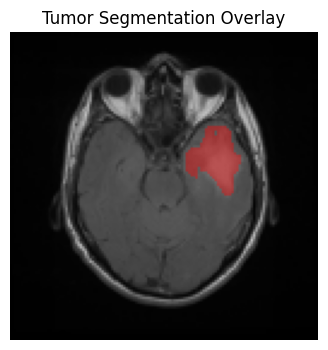

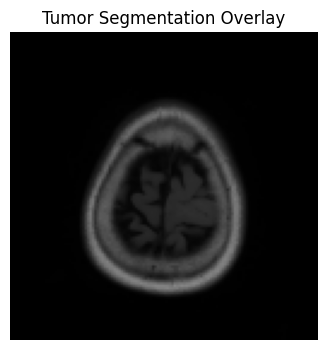

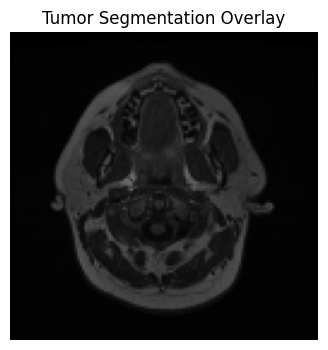

In [15]:
for i in range(5):

    image = X_test[i].reshape(128, 128)
    mask = predictions[i].reshape(128, 128)

    overlay = overlay_mask(image, mask)

    plt.figure(figsize=(4,4))

    plt.imshow(overlay)

    plt.title("Tumor Segmentation Overlay")

    plt.axis("off")

    plt.savefig(f"results/overlay_{i+1}.png", dpi=300)

    plt.show()

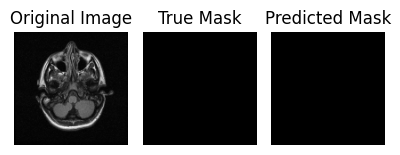

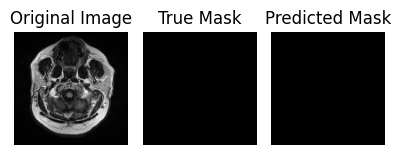

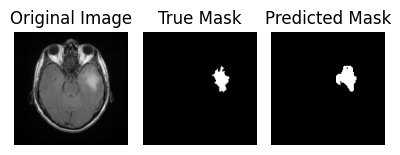

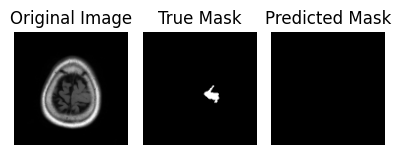

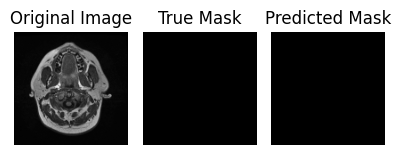

In [16]:
for i in range(5):
    plt.figure(figsize=(4, 2))

    plt.subplot(1, 3, 1)
    plt.imshow(X_test[i].reshape(128, 128), cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(y_test[i].reshape(128, 128), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predictions[i].reshape(128, 128), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"results/prediction_{i+1}.png", dpi=300)
    plt.show()

In [17]:
model.save("brain_mri_unet.h5")